In [29]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [30]:
dataset_path = r"F:\work\python\image frequency\landsat\2020 patch"   # folder with .tif images
output_path = r"F:\work\python\image frequency\landsat\Landsat_processed"

os.makedirs(output_path, exist_ok=True)

In [31]:
image_data = []

for band in os.listdir(dataset_path):
    band_path = os.path.join(dataset_path, band)

    for img_name in os.listdir(band_path):
        image_data.append({
            "path": os.path.join(band_path, img_name),
            "band": band
        })

print("Total images:", len(image_data))

Total images: 2040


In [32]:
def compute_edge_density(img):
    edges = cv2.Canny(img, 100, 200)
    return np.sum(edges > 0) / edges.size

data = []

for item in tqdm(image_data):
    
    img = cv2.imread(item["path"])
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (224, 224))

    intensity = np.mean(gray) / 255.0
    std_dev = np.std(gray) / 255.0
    edge_density = compute_edge_density(gray)

    score = 0.5 * intensity + 0.3 * std_dev + 0.2 * edge_density

    data.append({
        "path": item["path"],
        "band": item["band"],
        "intensity": intensity,
        "std": std_dev,
        "edge_density": edge_density,
        "score": score
    })

df = pd.DataFrame(data)
df.head()

100%|██████████| 2040/2040 [00:01<00:00, 1088.76it/s]


,path,band,intensity,std,edge_density,score
0,F:\work\python\image frequency\landsat\2020 pa...,B1,0.251682,0.028343,0.000000,0.134344
1,F:\work\python\image frequency\landsat\2020 pa...,B1,0.257879,0.032462,0.000000,0.138678
2,F:\work\python\image frequency\landsat\2020 pa...,B1,0.254404,0.034900,0.000000,0.137672
3,F:\work\python\image frequency\landsat\2020 pa...,B1,0.239533,0.044135,0.000000,0.133007
4,F:\work\python\image frequency\landsat\2020 pa...,B1,0.218099,0.041835,0.000538,0.121708


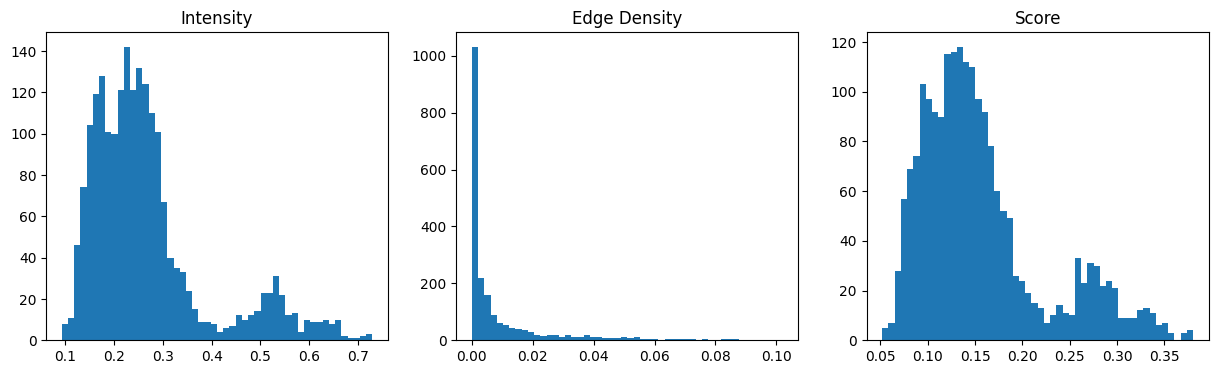

In [33]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(df["intensity"], bins=50)
plt.title("Intensity")

plt.subplot(1,3,2)
plt.hist(df["edge_density"], bins=50)
plt.title("Edge Density")

plt.subplot(1,3,3)
plt.hist(df["score"], bins=50)
plt.title("Score")

plt.show()

In [34]:
low_th = np.percentile(df["score"], 33)
high_th = np.percentile(df["score"], 66)

def categorize(row):
    if row["score"] < low_th:
        return "low"
    elif row["score"] < high_th:
        return "medium"
    else:
        return "high"

df["category"] = df.apply(categorize, axis=1)

print(df["category"].value_counts())

category
high      694
medium    673
low       673
Name: count, dtype: int64


In [35]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [36]:
for split in ["train", "test"]:
    for category in ["low", "medium", "high"]:
        for band in df["band"].unique():
            path = os.path.join(output_path, split, category, band)
            os.makedirs(path, exist_ok=True)

In [37]:
import shutil

def save_images(dataframe, split):
    
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        
        save_dir = os.path.join(
            output_path,
            split,
            row["category"],
            row["band"]
        )

        shutil.copy(row["path"], os.path.join(save_dir, os.path.basename(row["path"])))

save_images(train_df, "train")
save_images(test_df, "test")

print("Dataset saved successfully.")

100%|██████████| 408/408 [00:00<00:00, 1924.28it/s]

Dataset saved successfully.


In [38]:
df.to_csv("qilian_features.csv", index=False)

In [39]:
def load_dataset(path):
    return tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=(224, 224),
        batch_size=16,
        color_mode='grayscale'
    )

In [40]:
def preprocess(ds):
    ds = ds.map(lambda x, y: (x / 255.0, y))
    ds = ds.map(lambda x, y: (tf.image.grayscale_to_rgb(x), y))
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [41]:
low_train = preprocess(load_dataset(f"{output_path}/train/low"))
low_test  = preprocess(load_dataset(f"{output_path}/test/low"))

medium_train = preprocess(load_dataset(f"{output_path}/train/medium"))
medium_test  = preprocess(load_dataset(f"{output_path}/test/medium"))

high_train = preprocess(load_dataset(f"{output_path}/train/high"))
high_test  = preprocess(load_dataset(f"{output_path}/test/high"))

Found 529 files belonging to 8 classes.
Found 144 files belonging to 8 classes.
Found 553 files belonging to 8 classes.
Found 120 files belonging to 8 classes.
Found 550 files belonging to 8 classes.
Found 144 files belonging to 8 classes.


In [42]:
def build_simple_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.Flatten(),

        layers.Dense(128, activation='relu'),
        layers.Dense( len(os.listdir(f"{output_path}/train/low")), activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [43]:
def build_resnet():
    base = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense( len(os.listdir(f"{output_path}/train/low")), activation='softmax')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [44]:
def build_densenet():
    base = tf.keras.applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense( len(os.listdir(f"{output_path}/train/low")), activation='softmax')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [45]:
def train_model(model, train_ds, test_ds, name):

    print(f"\nTraining {name}...\n")

    history = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=10
    )

    loss, acc = model.evaluate(test_ds)
    print(f"{name} Accuracy:", acc)

    return history, acc

In [46]:
cnn_low = build_simple_cnn()
resnet_low = build_resnet()
dense_low = build_densenet()

cnn_low_hist, cnn_low_acc = train_model(cnn_low, low_train, low_test, "CNN Low")
resnet_low_hist, resnet_low_acc = train_model(resnet_low, low_train, low_test, "ResNet Low")
dense_low_hist, dense_low_acc = train_model(dense_low, low_train, low_test, "DenseNet Low")

C:\Users\gopik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN Low...

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 507ms/step - accuracy: 0.2476 - loss: 1.8585 - val_accuracy: 0.2014 - val_loss: 1.6752
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 486ms/step - accuracy: 0.2647 - loss: 1.6415 - val_accuracy: 0.2986 - val_loss: 1.6279
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 489ms/step - accuracy: 0.2401 - loss: 1.6258 - val_accuracy: 0.3056 - val_loss: 1.6103
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 489ms/step - accuracy: 0.3081 - loss: 1.5490 - val_accuracy: 0.2986 - val_loss: 1.5862
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 503ms/step - accuracy: 0.3403 - loss: 1.5012 - val_accuracy: 0.3542 - val_loss: 1.4912
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 515ms/step - accuracy: 0.4008 - loss: 1.3807 - val_accuracy: 0.4028 - val_loss: 1.3406
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 526ms/step - accuracy: 0.4423 - loss: 1.3007 - val_accuracy: 0.2778 - val_loss: 1.9083
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 526ms/step - accuracy: 0.5388 - l

In [47]:
cnn_med = build_simple_cnn()
resnet_med = build_resnet()
dense_med = build_densenet()

cnn_med_hist, cnn_med_acc = train_model(cnn_med, medium_train, medium_test, "CNN Medium")
resnet_med_hist, resnet_med_acc = train_model(resnet_med, medium_train, medium_test, "ResNet Medium")
dense_med_hist, dense_med_acc = train_model(dense_med, medium_train, medium_test, "DenseNet Medium")


Training CNN Medium...

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 503ms/step - accuracy: 0.1989 - loss: 2.2043 - val_accuracy: 0.2500 - val_loss: 1.8471
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 481ms/step - accuracy: 0.2315 - loss: 1.8712 - val_accuracy: 0.2500 - val_loss: 1.8242
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 480ms/step - accuracy: 0.2423 - loss: 1.8313 - val_accuracy: 0.2333 - val_loss: 1.8126
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 483ms/step - accuracy: 0.2712 - loss: 1.8061 - val_accuracy: 0.2083 - val_loss: 1.8964
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 505ms/step - accuracy: 0.2477 - loss: 1.7980 - val_accuracy: 0.2083 - val_loss: 1.8099
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 534ms/step - accuracy: 0.3526 - loss: 1.6756 - val_accuracy: 0.2250 - val_loss: 2.0264
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 568ms/step - accuracy: 0.4304 - loss: 1.4517 - val_accuracy: 0.2333 - val_loss: 2.2540
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 514ms/step - accuracy: 0.4684 

In [48]:
cnn_high = build_simple_cnn()
resnet_high = build_resnet()
dense_high = build_densenet()

cnn_high_hist, cnn_high_acc = train_model(cnn_high, high_train, high_test, "CNN High")
resnet_high_hist, resnet_high_acc = train_model(resnet_high, high_train, high_test, "ResNet High")
dense_high_hist, dense_high_acc = train_model(dense_high, high_train, high_test, "DenseNet High")


Training CNN High...

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 524ms/step - accuracy: 0.3727 - loss: 2.6487 - val_accuracy: 0.5347 - val_loss: 1.3489
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 531ms/step - accuracy: 0.4673 - loss: 1.3834 - val_accuracy: 0.5347 - val_loss: 1.2848
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 526ms/step - accuracy: 0.5200 - loss: 1.2288 - val_accuracy: 0.5347 - val_loss: 1.2395
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 507ms/step - accuracy: 0.5509 - loss: 1.2196 - val_accuracy: 0.5417 - val_loss: 1.2113
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 467ms/step - accuracy: 0.5600 - loss: 1.1704 - val_accuracy: 0.5417 - val_loss: 1.1753
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 462ms/step - accuracy: 0.5745 - loss: 1.1343 - val_accuracy: 0.5694 - val_loss: 1.1777
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 464ms/step - accuracy: 0.5873 - loss: 1.0541 - val_accuracy: 0.5625 - val_loss: 1.2331
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 479ms/step - accuracy: 0.6145 - 

In [49]:
print("\nFINAL RESULTS\n")

print("LOW:")
print("CNN:", cnn_low_acc)
print("ResNet:", resnet_low_acc)
print("DenseNet:", dense_low_acc)

print("\nMEDIUM:")
print("CNN:", cnn_med_acc)
print("ResNet:", resnet_med_acc)
print("DenseNet:", dense_med_acc)

print("\nHIGH:")
print("CNN:", cnn_high_acc)
print("ResNet:", resnet_high_acc)
print("DenseNet:", dense_high_acc)


FINAL RESULTS

LOW:
CNN: 0.4722222089767456
ResNet: 0.2013888955116272
DenseNet: 0.4791666567325592

MEDIUM:
CNN: 0.3333333432674408
ResNet: 0.25
DenseNet: 0.4166666567325592

HIGH:
CNN: 0.5277777910232544
ResNet: 0.4236111044883728
DenseNet: 0.5833333134651184


In [50]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [51]:
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 5   # increase to 10+ for better results

BASE_PATH = r"F:\work\python\image frequency\landsat\Landsat_processed"

In [52]:
def load_dataset(path):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        shuffle=True
    )

    class_names = ds.class_names

    # Normalize + convert to RGB
    ds = ds.map(lambda x, y: (x / 255.0, y))
    ds = ds.map(lambda x, y: (tf.image.grayscale_to_rgb(x), y))

    return ds.prefetch(tf.data.AUTOTUNE), class_names

In [53]:
low_train, low_classes = load_dataset(f"{BASE_PATH}/train/low")
low_test, _ = load_dataset(f"{BASE_PATH}/test/low")

medium_train, medium_classes = load_dataset(f"{BASE_PATH}/train/medium")
medium_test, _ = load_dataset(f"{BASE_PATH}/test/medium")

high_train, high_classes = load_dataset(f"{BASE_PATH}/train/high")
high_test, _ = load_dataset(f"{BASE_PATH}/test/high")

Found 529 files belonging to 8 classes.
Found 144 files belonging to 8 classes.
Found 553 files belonging to 8 classes.
Found 120 files belonging to 8 classes.
Found 550 files belonging to 8 classes.
Found 144 files belonging to 8 classes.


In [58]:
def build_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation='relu'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [59]:
def build_resnet(num_classes):
    base = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [60]:
def build_efficientnet(num_classes):
    base = tf.keras.applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [61]:
def train_and_evaluate(train_ds, test_ds, class_names, category):

    num_classes = len(class_names)

    results = {}

    print(f"\n===== {category.upper()} CATEGORY =====")

    # 🔹 CNN
    cnn = build_cnn(num_classes)
    cnn.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, verbose=1)
    _, acc = cnn.evaluate(test_ds, verbose=0)
    results["CNN"] = acc
    print(f"CNN Accuracy: {acc:.4f}")

    # 🔹 ResNet50
    resnet = build_resnet(num_classes)
    resnet.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, verbose=1)
    _, acc = resnet.evaluate(test_ds, verbose=0)
    results["ResNet50"] = acc
    print(f"ResNet50 Accuracy: {acc:.4f}")

    # 🔹 EfficientNet
    eff = build_efficientnet(num_classes)
    eff.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, verbose=1)
    _, acc = eff.evaluate(test_ds, verbose=0)
    results["EfficientNet"] = acc
    print(f"EfficientNet Accuracy: {acc:.4f}")

    return results

In [62]:
low_results = train_and_evaluate(low_train, low_test, low_classes, "Low")

medium_results = train_and_evaluate(medium_train, medium_test, medium_classes, "Medium")

high_results = train_and_evaluate(high_train, high_test, high_classes, "High")


===== LOW CATEGORY =====
Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.2363 - loss: 1.7916 - val_accuracy: 0.2014 - val_loss: 1.7060
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.2155 - loss: 1.6442 - val_accuracy: 0.2014 - val_loss: 1.6892
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.2514 - loss: 1.6359 - val_accuracy: 0.2014 - val_loss: 1.6822
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.2287 - loss: 1.6444 - val_accuracy: 0.2014 - val_loss: 1.6719
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.2609 - loss: 1.6224 - val_accuracy: 0.3542 - val_loss: 1.6376
CNN Accuracy: 0.3542
Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - accuracy: 0.2155 - loss: 1.7729 - val_accuracy: 0.2986 - val_loss: 1.6623
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.2420 - loss: 1.6168 - val_accuracy: 0.2014 - val_loss: 1.6503
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.217

In [63]:
results_df = pd.DataFrame({
    "Low": low_results,
    "Medium": medium_results,
    "High": high_results
}).T

print("\nFINAL RESULTS:\n")
print(results_df)


FINAL RESULTS:

             CNN  ResNet50  EfficientNet
Low     0.354167  0.201389      0.298611
Medium  0.208333  0.208333      0.208333
High    0.534722  0.416667      0.375000


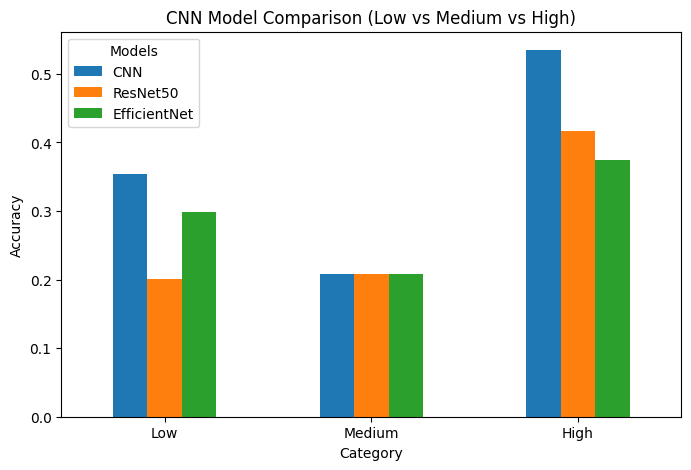

In [64]:
results_df.plot(kind='bar', figsize=(8,5))
plt.title("CNN Model Comparison (Low vs Medium vs High)")
plt.ylabel("Accuracy")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.legend(title="Models")
plt.show()

In [65]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.cluster import KMeans
import shutil

In [66]:
INPUT_PATH = r"F:\work\python\image frequency\landsat\2020 patch"   # folder with .tif images
OUTPUT_PATH= r"F:\work\python\image frequency\landsat\Landsat_processed"


os.makedirs(OUTPUT_PATH, exist_ok=True)

In [67]:
bands = ["B1","B2","B3","B4","B5","B6","B7","B8"]

file_list = sorted(os.listdir(os.path.join(INPUT_PATH, "B1")))
print("Total samples:", len(file_list))

Total samples: 255


In [68]:
def load_multiband_image(filename):

    b2 = cv2.imread(f"{INPUT_PATH}/B2/{filename}", 0)
    b3 = cv2.imread(f"{INPUT_PATH}/B3/{filename}", 0)
    b4 = cv2.imread(f"{INPUT_PATH}/B4/{filename}", 0)

    if b2 is None or b3 is None or b4 is None:
        return None

    img = np.stack([b4, b3, b2], axis=-1)  # RGB
    img = cv2.resize(img, (128,128))

    return img

In [69]:
def compute_features(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    intensity = np.mean(gray) / 255.0
    std = np.std(gray) / 255.0

    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    return [intensity, std, edge_density]

In [70]:
data = []

for fname in tqdm(file_list):

    img = load_multiband_image(fname)
    if img is None:
        continue

    features = compute_features(img)

    data.append({
        "filename": fname,
        "intensity": features[0],
        "std": features[1],
        "edge": features[2]
    })

df = pd.DataFrame(data)

100%|██████████| 255/255 [00:06<00:00, 41.42it/s]


In [71]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(df[["intensity","std","edge"]])

# Sort clusters → low, medium, high
cluster_mean = df.groupby("cluster")["intensity"].mean().sort_values()

mapping = {
    cluster_mean.index[0]: "low",
    cluster_mean.index[1]: "medium",
    cluster_mean.index[2]: "high"
}

df["category"] = df["cluster"].map(mapping)
print(df["category"].value_counts())

category
low       150
medium     61
high       44
Name: count, dtype: int64


In [72]:
for category in ["low","medium","high"]:
    os.makedirs(f"{OUTPUT_PATH}/{category}", exist_ok=True)

for _, row in tqdm(df.iterrows(), total=len(df)):

    img = load_multiband_image(row["filename"])
    save_path = f"{OUTPUT_PATH}/{row['category']}/{row['filename']}"

    cv2.imwrite(save_path, img)

print("Dataset created.")

100%|██████████| 255/255 [00:00<00:00, 363.64it/s]

Dataset created.


In [73]:
import pywt

def compute_dwt(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray.astype(np.float32) / 255.0

    coeffs = pywt.dwt2(gray, 'haar')
    LL, (LH, HL, HH) = coeffs

    # Resize to match
    LH = cv2.resize(LH, (128,128))
    HL = cv2.resize(HL, (128,128))
    HH = cv2.resize(HH, (128,128))

    dwt_img = np.stack([LH, HL, HH], axis=-1)

    return dwt_img

In [74]:
import tensorflow as tf

class MultiInputGenerator(tf.keras.utils.Sequence):

    def __init__(self, folder, batch_size=16):
        self.folder = folder
        self.batch_size = batch_size

        self.classes = os.listdir(folder)
        self.filepaths = []
        self.labels = []

        for i, cls in enumerate(self.classes):
            cls_path = os.path.join(folder, cls)

            for fname in os.listdir(cls_path):
                self.filepaths.append(os.path.join(cls_path, fname))
                self.labels.append(i)

    def __len__(self):
        return len(self.filepaths) // self.batch_size

    def __getitem__(self, idx):

        batch_x = self.filepaths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_y = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        rgb_batch = []
        dwt_batch = []

        for path in batch_x:
            img = cv2.imread(path)
            img = cv2.resize(img, (128,128)) / 255.0

            dwt_img = compute_dwt(img)

            rgb_batch.append(img)
            dwt_batch.append(dwt_img)

        return [np.array(rgb_batch), np.array(dwt_batch)], np.array(batch_y)

In [75]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

def build_hybrid_model():

    # RGB branch
    rgb_input = layers.Input(shape=(128,128,3))

    base = EfficientNetB0(weights='imagenet',
                          include_top=False,
                          input_tensor=rgb_input)

    for layer in base.layers[:-20]:
        layer.trainable = False

    x1 = layers.GlobalAveragePooling2D()(base.output)

    # DWT branch
    dwt_input = layers.Input(shape=(128,128,3))

    x2 = layers.Conv2D(32,3,activation='relu')(dwt_input)
    x2 = layers.MaxPooling2D()(x2)

    x2 = layers.Conv2D(64,3,activation='relu')(x2)
    x2 = layers.GlobalAveragePooling2D()(x2)

    # Fusion
    x = layers.concatenate([x1, x2])

    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(3, activation='softmax')(x)

    model = Model(inputs=[rgb_input, dwt_input], outputs=output)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [78]:
train_gen = MultiInputGenerator("OUTPUT_PATH", batch_size=16)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'OUTPUT_PATH'